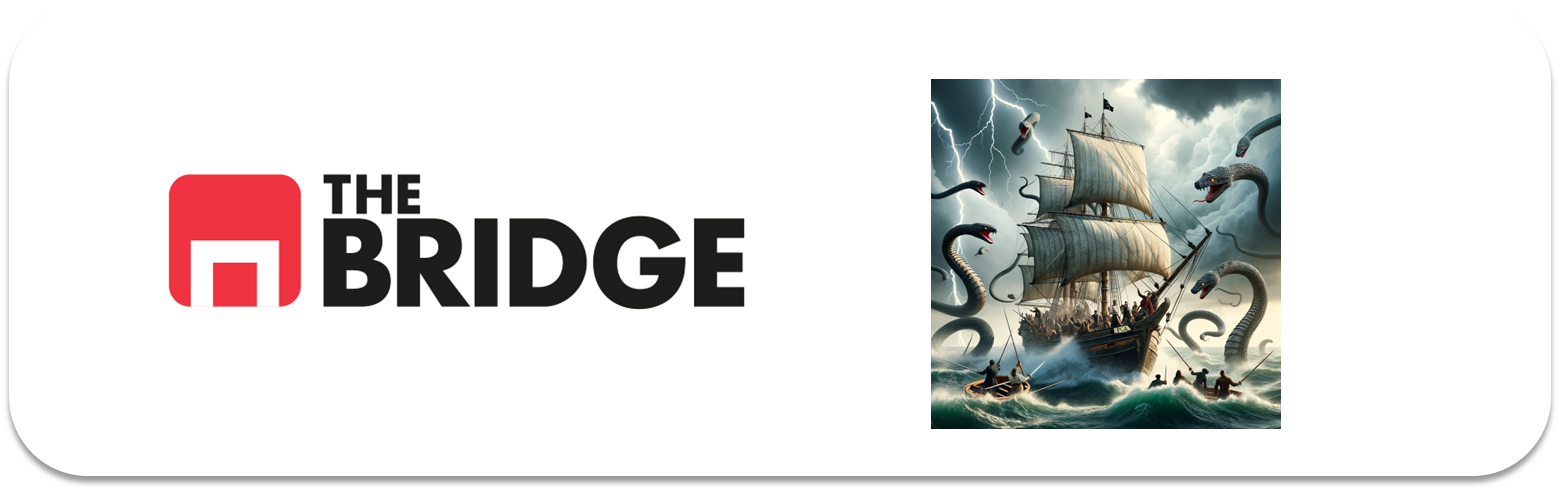

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score
from sklearn.decomposition import PCA

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




Descargando el dataset Olivetti Faces...

--- Mini EDA ---
Forma del dataset: (400, 4097) (400 filas, 4096 columnas de píxeles + 1 target)
Balanceo de clases (primeras 5 personas):
target
0    10
1    10
2    10
3    10
4    10
Name: count, dtype: int64


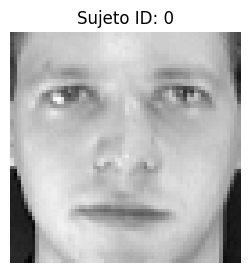


Entrenando y evaluando con Cross Validation (CV=5)...
Entrenando modelo final sobre todo el conjunto de Train...
Prediciendo sobre el conjunto de Test...

 RESULTADOS DEL MODELO BASELINE (SIN COMPRIMIR)
Balanced Accuracy Media (CV=5): 0.9625
Balanced Accuracy (Test):       0.9750


In [2]:
# ==========================================
# 1. CARGA DE DATOS Y CREACIÓN DEL DATAFRAME
# ==========================================
print("Descargando el dataset Olivetti Faces...")
faces = fetch_olivetti_faces()

# X contiene 400 imágenes. Cada imagen es de 64x64 píxeles.
# Al aplanarse, cada imagen se convierte en un vector de 4096 features.
X = faces.data 
y = faces.target # 40 personas diferentes (clases de la 0 a la 39)

# Construir el DataFrame
df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df['target'] = y

# ==========================================
# 2. MINI EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- Mini EDA ---")
print(f"Forma del dataset: {df.shape} (400 filas, 4096 columnas de píxeles + 1 target)")
print("Balanceo de clases (primeras 5 personas):")
print(df['target'].value_counts().head())

# Justificación del miniEDA: 
# Este dataset está curado de antemano. No tiene nulos, los píxeles ya están 
# escalados entre 0 y 1, y está perfectamente balanceado (10 fotos por persona).
# Por tanto, no requerimos transformaciones previas. Visualizamos una cara de ejemplo:

plt.figure(figsize=(3, 3))
plt.imshow(X[0].reshape(64, 64), cmap='gray')
plt.title(f"Sujeto ID: {y[0]}")
plt.axis('off')
plt.show()

# ==========================================
# 3. SPLIT EN TRAIN Y TEST
# ==========================================
# Separamos features (X) del target (y)
X_df = df.drop(columns=['target'])
y_df = df['target']

# Hacemos el split. El total son 400 instancias.
# Nos piden al menos 80 instancias en test. test_size=80 cumple exactamente esto (20%).
# Al estratificar por 'y_df', garantizamos que de las 10 fotos de cada persona, 
# 8 vayan a train y 2 vayan a test.
X_train, X_test, y_train, y_test = train_test_split(
    X_df, 
    y_df, 
    test_size=80, 
    stratify=y_df, 
    random_state=42
)

# ==========================================
# 4. MODELADO Y EVALUACIÓN BASELINE
# ==========================================
# Elegimos un Support Vector Classifier (SVC). Los SVM con kernel lineal 
# suelen funcionar extraordinariamente bien en espacios de alta dimensionalidad
# (como nuestras 4096 columnas de píxeles).
model_baseline = SVC(kernel='linear', random_state=42)

print("\nEntrenando y evaluando con Cross Validation (CV=5)...")
# Usamos scoring='balanced_accuracy' como pide el enunciado
cv_scores = cross_val_score(model_baseline, X_train, y_train, cv=5, scoring='balanced_accuracy')
baseline_cv_score = cv_scores.mean()

print("Entrenando modelo final sobre todo el conjunto de Train...")
model_baseline.fit(X_train, y_train)

print("Prediciendo sobre el conjunto de Test...")
y_pred = model_baseline.predict(X_test)
baseline_test_score = balanced_accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(" RESULTADOS DEL MODELO BASELINE (SIN COMPRIMIR)")
print("="*40)
print(f"Balanced Accuracy Media (CV=5): {baseline_cv_score:.4f}")
print(f"Balanced Accuracy (Test):       {baseline_test_score:.4f}")
print("="*40)

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [5]:
# ==========================================
# 1. INSTANCIAR Y ENTRENAR PCA (Sin argumentos)
# ==========================================
# Al no pasarle argumentos, PCA calculará el número máximo posible de componentes 
# (que es el mínimo entre el número de filas y columnas, en este caso 320 componentes).
pca = PCA(random_state=42)
pca.fit(X_train) 

# ==========================================
# 2. SELECCIONAR RANGO DE COMPONENTES
# ==========================================
# El tamaño original es 4096 features.
# - 0.2% de 4096 = 8.19 (aprox 9 componentes)
# - 2.5% de 4096 = 102.4 (aprox 102 componentes)
# Escogemos 5 valores repartidos en este rango:
componentes_prueba = [9, 25, 50, 75, 100]

# ==========================================
# 3. ENTRENAMIENTO Y EVALUACIÓN POR RANGO
# ==========================================
resultados = []

for n in componentes_prueba:
    # Gracias a que hemos entrenado el PCA completo antes, podemos simplemente 
    # transformar los datos y "recortar" las primeras 'n' columnas para comprimir.
    X_train_pca = pca.transform(X_train)[:, :n]
    X_test_pca = pca.transform(X_test)[:, :n]
    
    # Usamos el mismo modelo base (SVC lineal) para que la comparación sea justa
    modelo = SVC(kernel='linear', random_state=42)
    
    # Validación cruzada (CV=5)
    cv_scores = cross_val_score(modelo, X_train_pca, y_train, cv=5, scoring='balanced_accuracy')
    score_cv = cv_scores.mean()
    
    # Score contra Test
    modelo.fit(X_train_pca, y_train)
    y_pred = modelo.predict(X_test_pca)
    score_test = balanced_accuracy_score(y_test, y_pred)
    
    # ==========================================
    # 4. CÁLCULO DE MÉTRICAS Y GUARDADO
    # ==========================================
    # Compresión = (n_componentes / tamaño_original) * 100
    compresion_pct = (n / X_train.shape[1]) * 100
    
    # Diferencia de pérdida de rendimiento (Baseline - Nuevo Score)
    perdida_cv = baseline_cv_score - score_cv
    perdida_test = baseline_test_score - score_test
    
    resultados.append({
        'Componentes': n,
        'Compresion_%': compresion_pct,
        'Score_CV': score_cv,
        'Score_Test': score_test,
        'Perdida_CV': perdida_cv,
        'Perdida_Test': perdida_test
    })

# Convertimos a DataFrame para visualizarlo
df_resultados = pd.DataFrame(resultados)
print("--- TABLA DE RESULTADOS DE COMPRESIÓN ---")
display(df_resultados) # Si usas script puro en lugar de Jupyter, usa print(df_resultados)

# ==========================================
# 5. ESCOGER LA MEJOR OPCIÓN (BUSINESS LOGIC)
# ==========================================
# Filtramos buscando pérdida inferior a 3 puntos (0.03)
condicion_3_pct = (df_resultados['Perdida_CV'] < 0.03) & (df_resultados['Perdida_Test'] < 0.03)
candidatos_3_pct = df_resultados[condicion_3_pct]

print("\n" + "="*50)
if not candidatos_3_pct.empty:
    # Como los candidatos ya están ordenados de menor a mayor número de componentes,
    # el primero (.iloc[0]) será el que ofrezca MAYOR compresión cumpliendo la regla.
    mejor_opcion = candidatos_3_pct.iloc[0]
    print(" RECOMENDACIÓN PARA EL CASINO (Pérdida < 3%)")
else:
    # Si no hay ninguno con < 3%, buscamos con < 5% (0.05)
    print(" No hay opciones con pérdida < 3%. Buscando con pérdida < 5%...")
    condicion_5_pct = (df_resultados['Perdida_CV'] < 0.05) & (df_resultados['Perdida_Test'] < 0.05)
    candidatos_5_pct = df_resultados[condicion_5_pct]
    mejor_opcion = candidatos_5_pct.iloc[0]
    print(" RECOMENDACIÓN PARA EL CASINO (Pérdida < 5%)")
print("="*50)

print(mejor_opcion)

--- TABLA DE RESULTADOS DE COMPRESIÓN ---


,Componentes,Compresion_%,Score_CV,Score_Test,Perdida_CV,Perdida_Test
0,9,0.219727,0.84,0.900,0.1225,0.075
1,25,0.610352,0.95,0.950,0.0125,0.025
2,50,1.220703,0.96,0.975,0.0025,0.000
3,75,1.831055,0.96,0.975,0.0025,0.000
4,100,2.441406,0.96,0.975,0.0025,0.000



 RECOMENDACIÓN PARA EL CASINO (Pérdida < 3%)
Componentes     25.000000
Compresion_%     0.610352
Score_CV         0.950000
Score_Test       0.950000
Perdida_CV       0.012500
Perdida_Test     0.025000
Name: 1, dtype: float64


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

--- RESULTADOS SOBRE IMÁGENES DESCOMPRIMIDAS (UNZIPPED) ---


,Componentes,Compresion_%,Score_Test_Unzipped,Perdida_Test
0,4,0.097656,0.5250,0.4500
1,10,0.244141,0.9000,0.0750
2,20,0.488281,0.9375,0.0375
3,30,0.732422,0.9625,0.0125
4,41,1.000977,0.9625,0.0125


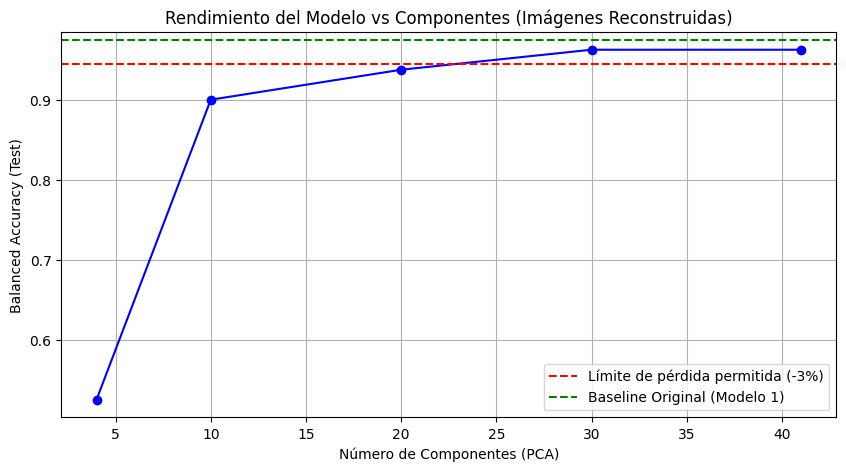


 RECOMENDACIÓN FINAL PARA EL SERVIDOR CENTRAL: 30 COMPONENTES
 Motivo: Comprime al 0.73% de su tamaño original,
 pero al reconstruir la imagen perdemos solo 1.25% de accuracy.


In [6]:
# ==========================================
# 1. ESCOGER RANGO DE VALORES (0.1% al 1%)
# ==========================================
# Total de features originales = 4096. 
# 0.1% de 4096 = 4.096 (aprox 4 componentes)
# 1.0% de 4096 = 40.96 (aprox 41 componentes)
# Escogemos 5 valores en este rango:
componentes_rango = [4, 10, 20, 30, 41]

resultados_unzipped = []

# ==========================================
# 2. APLICAR PCA, RECONSTRUIR Y ENTRENAR
# ==========================================
for n in componentes_rango:
    # Instanciamos PCA con el número de componentes actual
    pca = PCA(n_components=n, random_state=42)
    
    # 1. Comprimimos el Train (fit_transform)
    X_train_pca = pca.fit_transform(X_train)
    # 2. Reconstruimos la imagen a sus 4096 píxeles (inverse_transform)
    X_train_unzipped = pca.inverse_transform(X_train_pca)
    
    # IMPORTANTE: Aplicar la misma transformación y reconstrucción al Test
    X_test_pca = pca.transform(X_test)
    X_test_unzipped = pca.inverse_transform(X_test_pca)
    
    # Entrenar el modelo con los datos reconstruidos (Unzipped)
    modelo = SVC(kernel='linear', random_state=42)
    modelo.fit(X_train_unzipped, y_train)
    
    # Predecir sobre el Test reconstruido
    y_pred = modelo.predict(X_test_unzipped)
    score_test = balanced_accuracy_score(y_test, y_pred)
    
    # Calcular métricas
    compresion_pct = (n / 4096) * 100
    perdida_test = baseline_test_score - score_test
    
    resultados_unzipped.append({
        'Componentes': n,
        'Compresion_%': compresion_pct,
        'Score_Test_Unzipped': score_test,
        'Perdida_Test': perdida_test
    })

# ==========================================
# 3. CREAR DATAFRAME Y VISUALIZACIÓN
# ==========================================
df_unzipped = pd.DataFrame(resultados_unzipped)
print("--- RESULTADOS SOBRE IMÁGENES DESCOMPRIMIDAS (UNZIPPED) ---")
display(df_unzipped) # Usa print(df_unzipped) si no estás en Jupyter

# Vamos a crear la gráfica visual para la presentación de negocio
plt.figure(figsize=(10, 5))
plt.plot(df_unzipped['Componentes'], df_unzipped['Score_Test_Unzipped'], marker='o', linestyle='-', color='b')

# Líneas de referencia
limite_perdida = baseline_test_score - 0.03
plt.axhline(y=limite_perdida, color='r', linestyle='--', label='Límite de pérdida permitida (-3%)')
plt.axhline(y=baseline_test_score, color='g', linestyle='--', label='Baseline Original (Modelo 1)')

plt.title('Rendimiento del Modelo vs Componentes (Imágenes Reconstruidas)')
plt.xlabel('Número de Componentes (PCA)')
plt.ylabel('Balanced Accuracy (Test)')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 4. DECISIÓN DE NEGOCIO
# ==========================================
# Filtrar aquellas opciones que tienen una pérdida <= 3% (0.03)
opciones_validas = df_unzipped[df_unzipped['Perdida_Test'] <= 0.03]

print("\n" + "="*60)
if not opciones_validas.empty:
    mejor_opcion_unzipped = opciones_validas.iloc[0]
    print(f" RECOMENDACIÓN FINAL PARA EL SERVIDOR CENTRAL: {int(mejor_opcion_unzipped['Componentes'])} COMPONENTES")
    print(f" Motivo: Comprime al {mejor_opcion_unzipped['Compresion_%']:.2f}% de su tamaño original,")
    print(f" pero al reconstruir la imagen perdemos solo {(mejor_opcion_unzipped['Perdida_Test']*100):.2f}% de accuracy.")
else:
    print(" CUIDADO: Con este nivel tan extremo de compresión (0.1% - 1%),")
    print(" ninguna opción mantiene la pérdida por debajo del 3% requerido al reconstruir.")
print("="*60)

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

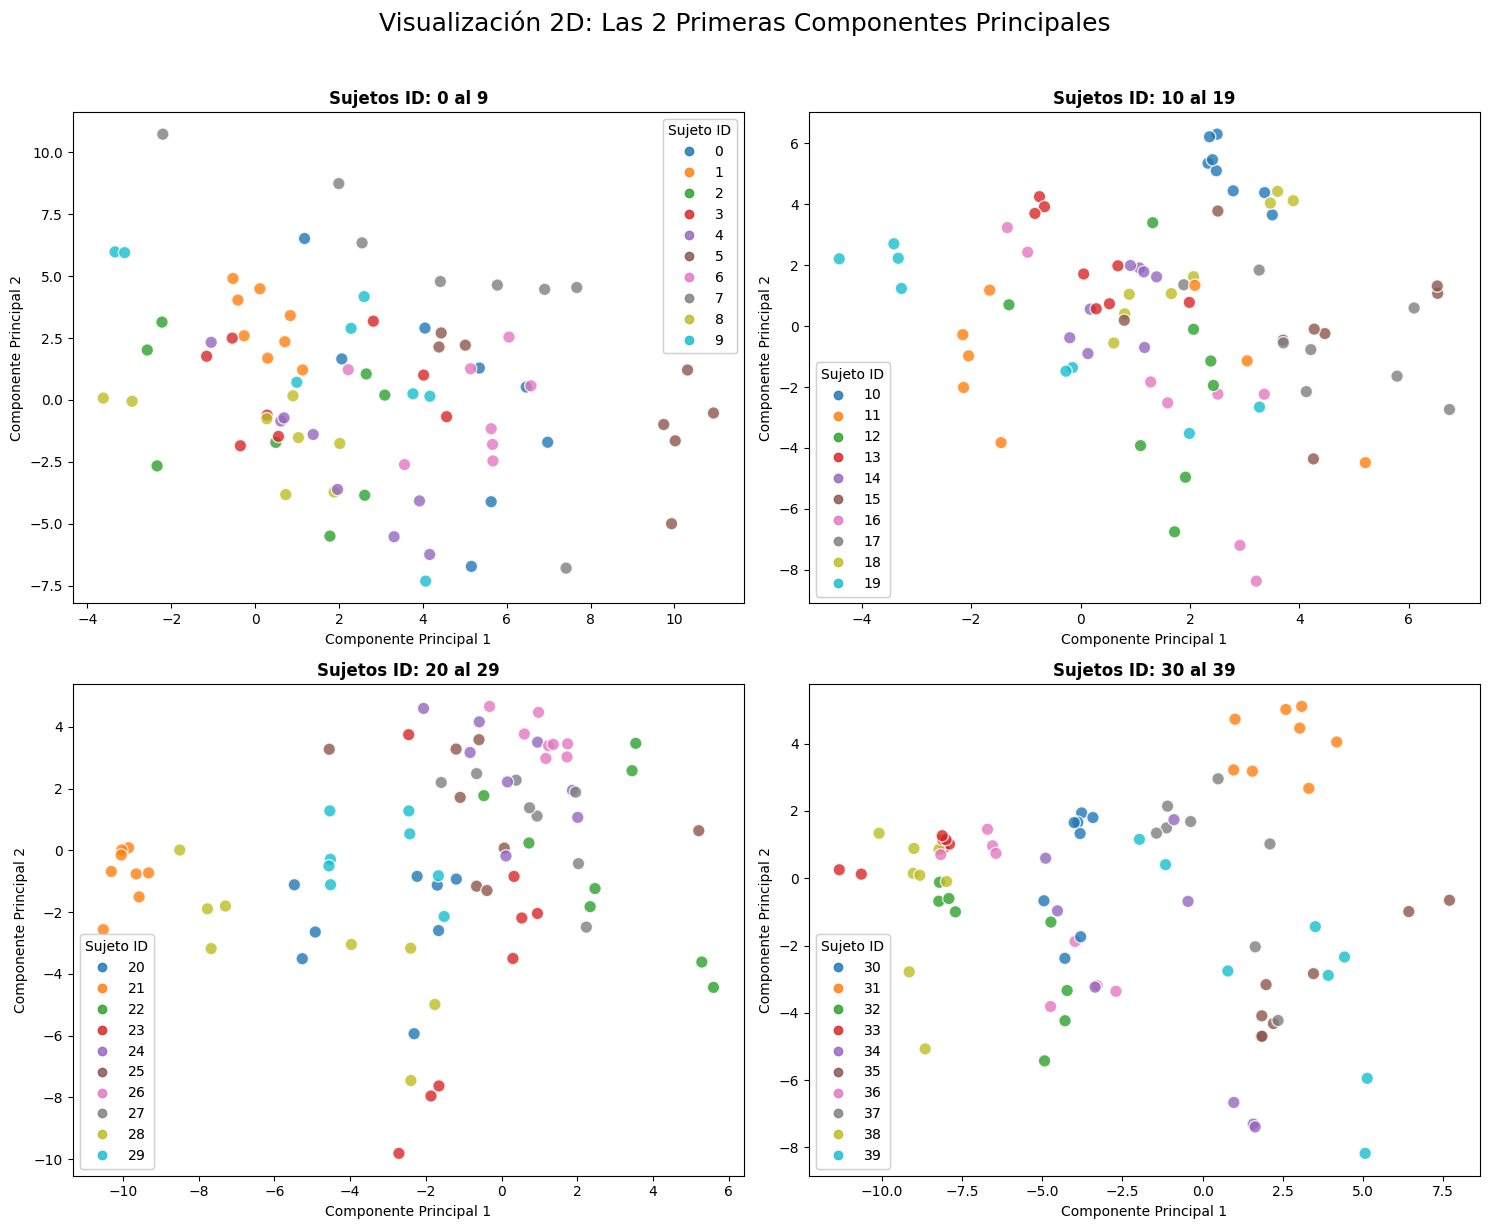

In [ ]:
#1

# 1. Hacemos el PCA escogido (usaremos 30 componentes como ejemplo de tu resultado anterior)
pca = PCA(n_components=30, random_state=42)
# Como X_train es un DataFrame, usamos .values para evitar problemas de índices
X_train_pca = pca.fit_transform(X_train.values) 

# 2. Creamos la figura con 4 subgráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Aplanamos la matriz de gráficos para iterar del 0 al 3

# 3. Iteramos para crear los 4 gráficos en bloques de 10 personas
for i in range(4):
    # Definimos el rango de clases (Personas 0-9, 10-19, 20-29, 30-39)
    start_class = i * 10
    end_class = (i + 1) * 10
    
    # Filtramos solo las instancias que pertenecen a estas 10 clases
    mask = (y_train.values >= start_class) & (y_train.values < end_class)
    X_subset = X_train_pca[mask]
    y_subset = y_train.values[mask]
    
    ax = axes[i]
    # Dibujamos el scatter plot usando solo la Componente 1 (columna 0) y Componente 2 (columna 1)
    scatter = ax.scatter(X_subset[:, 0], X_subset[:, 1], c=y_subset, cmap='tab10', alpha=0.8, edgecolors='w', s=80)
    
    ax.set_title(f'Sujetos ID: {start_class} al {end_class - 1}', fontweight='bold')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    
    # Añadimos la leyenda de colores
    legend = ax.legend(*scatter.legend_elements(), title="Sujeto ID", loc="best")
    ax.add_artist(legend)

plt.suptitle('Visualización 2D: Las 2 Primeras Componentes Principales', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

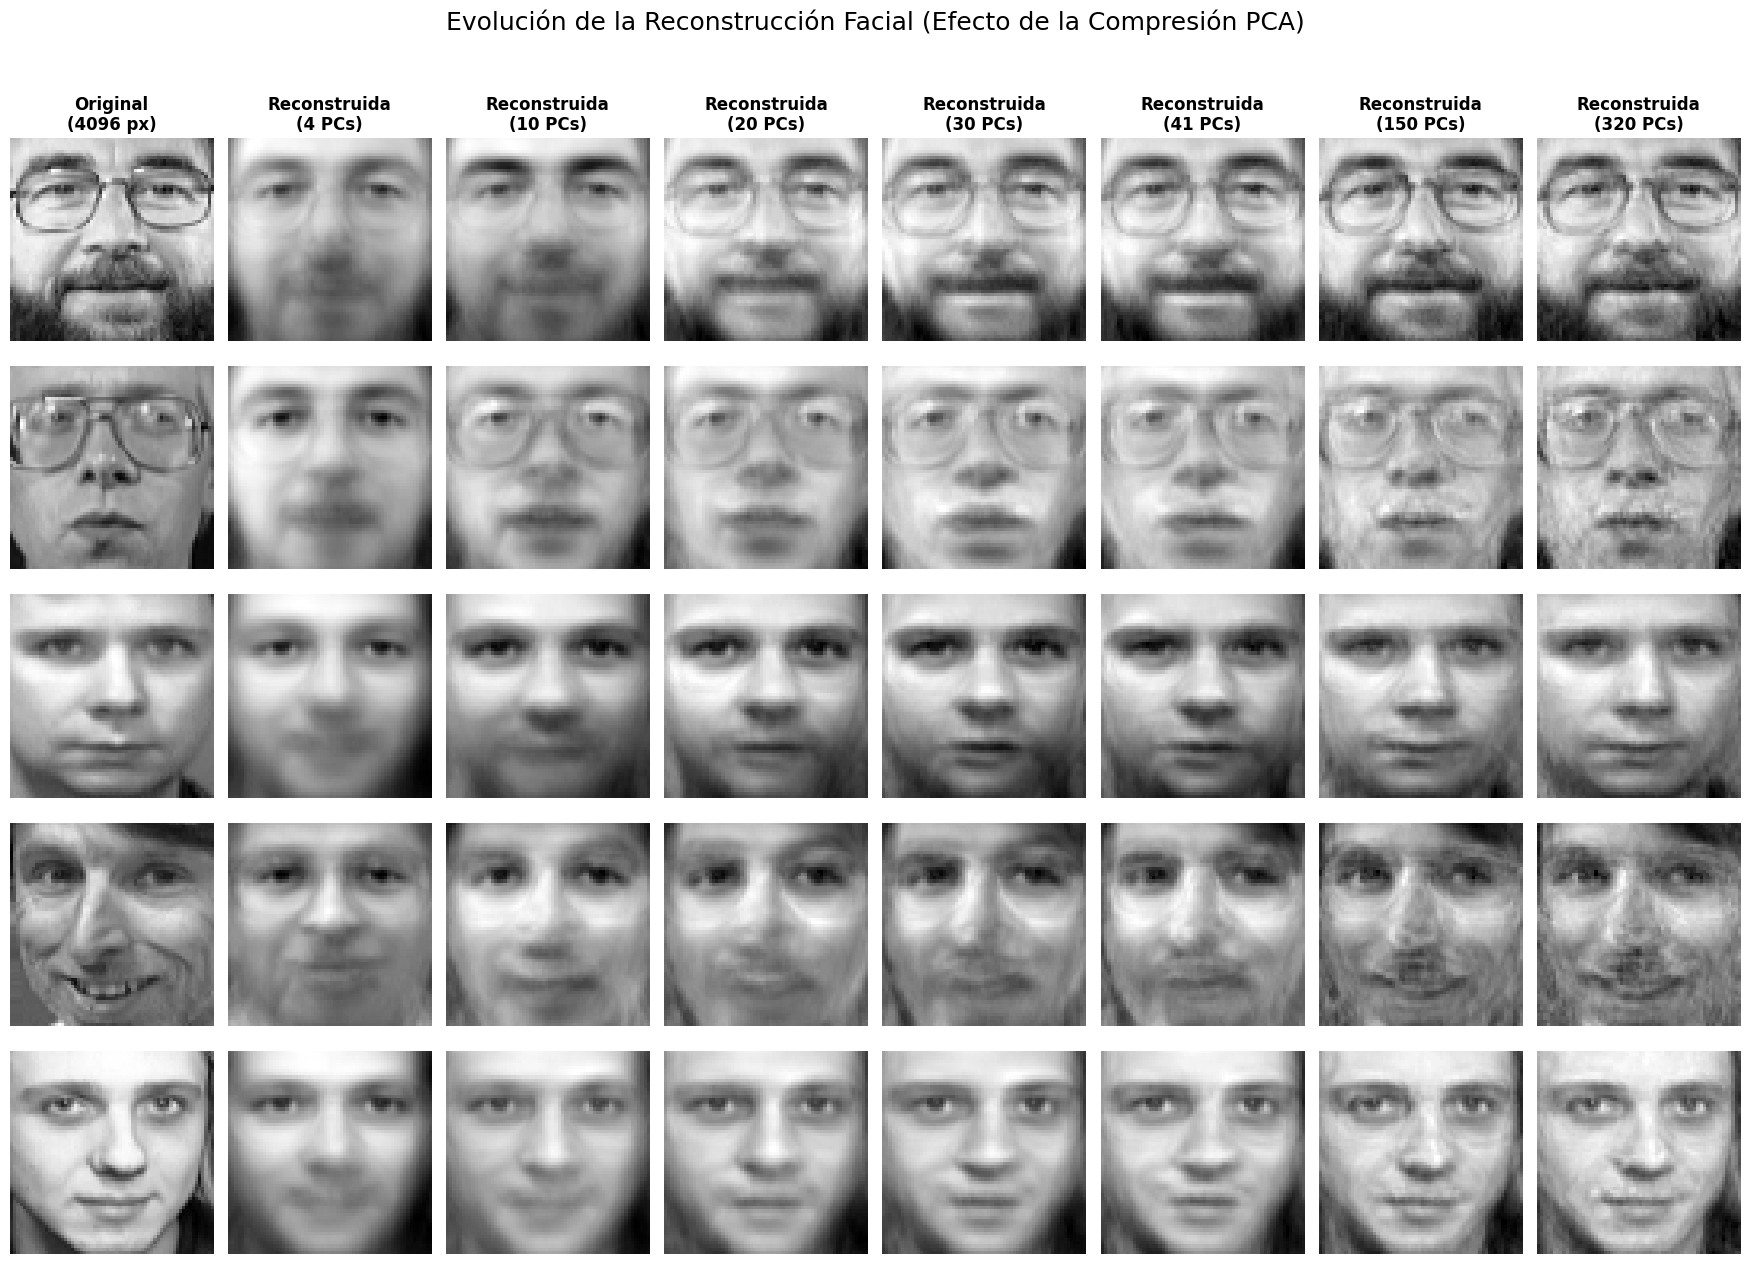

In [9]:
#2

def visualizar_reconstruccion_pca(X_train, X_test, n_components_list, n_faces=5):
    """
    Función que comprime y descomprime caras para ver el efecto del PCA visualmente.
    """
    # Elegimos 5 caras aleatorias del conjunto de Test
    np.random.seed(42)
    # Como X_test tiene 80 filas, cogemos 5 índices al azar
    indices_aleatorios = np.random.choice(range(len(X_test)), n_faces, replace=False)
    
    # Preparar la figura tipo cuadrícula (5 filas x número de columnas)
    n_cols = len(n_components_list) + 1
    fig, axes = plt.subplots(n_faces, n_cols, figsize=(2.2 * n_cols, 2.5 * n_faces))
    
    for i, idx in enumerate(indices_aleatorios):
        # 1. DIBUJAR LA CARA ORIGINAL
        # Extraemos la fila con .iloc y la convertimos en matriz 64x64
        cara_original = X_test.iloc[idx].values.reshape(64, 64) 
        axes[i, 0].imshow(cara_original, cmap='gray')
        axes[i, 0].axis('off')
        if i == 0: axes[i, 0].set_title("Original\n(4096 px)", fontweight='bold')
            
        # 2. DIBUJAR LAS RECONSTRUCCIONES PARA CADA VALOR DE PCA
        for j, n_pc in enumerate(n_components_list):
            # Entrenamos el compresor
            pca = PCA(n_components=n_pc, random_state=42)
            pca.fit(X_train.values) 
            
            # Cogemos la cara original, la comprimimos y la volvemos a descomprimir
            cara_plana = X_test.iloc[idx].values.reshape(1, -1)
            cara_comprimida = pca.transform(cara_plana)
            cara_reconstruida = pca.inverse_transform(cara_comprimida).reshape(64, 64)
            
            # Dibujamos el resultado
            axes[i, j+1].imshow(cara_reconstruida, cmap='gray')
            axes[i, j+1].axis('off')
            if i == 0: axes[i, j+1].set_title(f"Reconstruida\n({n_pc} PCs)", fontweight='bold')

    plt.suptitle('Evolución de la Reconstrucción Facial (Efecto de la Compresión PCA)', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

# Lista de componentes (Tus 5 pruebas + los dos extremos que pide el enunciado)
componentes_a_probar = [4, 10, 20, 30, 41, 150, 320]

# Llamamos a la función
visualizar_reconstruccion_pca(X_train, X_test, componentes_a_probar, n_faces=5)